In [29]:
train_data_location = "../data/train"
test_data_location = "../data/test"
val_data_location = "../data/val"

In [ ]:
# Imports
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np


In [31]:
data_dir = "../data"
image_ext = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

for split in os.listdir(data_dir):  # train / val / test
    split_path = os.path.join(data_dir, split)

    if os.path.isdir(split_path):
        print(f"\n{split.upper()}")

        for category in os.listdir(split_path):  # ripe / overripe / ...
            category_path = os.path.join(split_path, category)

            if os.path.isdir(category_path):
                count = sum(
                    1 for f in os.listdir(category_path)
                    if f.lower().endswith(image_ext)
                )

                print(f"{category}: {count}")


TEST
overripe: 8
ripe: 8
spotty: 8
underripe: 10

TRAIN
overripe: 17
ripe: 50
spotty: 22
underripe: 49

VAL
overripe: 8
ripe: 8
spotty: 8
underripe: 10


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
train_data = datasets.ImageFolder("../data/train", transform=train_transform)
val_data = datasets.ImageFolder("../data/val", transform=val_test_transform)
test_data = datasets.ImageFolder("../data/test", transform=val_test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(train_data.class_to_idx)

{'overripe': 0, 'ripe': 1, 'spotty': 2, 'underripe': 3}


In [ ]:
model = models.mobilenet_v2(weights='DEFAULT')

for param in model.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(1280, 4) 
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

In [ ]:
# Defining a function to evaluate the model
def evaluate_model(model, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

In [ ]:
epochs = 12
best_val_acc = 0.0
save_path = '../saved_models/MobileNet.pth'

print(f"Starting Training on {device}...")

for epoch in range(epochs):
    # Training Phase
    model.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation Phase
    val_loss, val_acc = evaluate_model(model, val_loader)
    
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Save the model if it has the best validation accuracy so far
    if val_acc >= best_val_acc:
        best_val_acc = val_acc
        print(f"New best accuracy! Saving model to {save_path}")
        torch.save(model.state_dict(), save_path)


Starting Training on cpu...
Epoch 1/12
Train Loss: 1.3542 | Val Loss: 0.9899 | Val Acc: 29.41%
✨ New best accuracy! Saving model to ../saved_models/MobileNet.pth
Epoch 2/12
Train Loss: 1.0557 | Val Loss: 0.8409 | Val Acc: 47.06%
✨ New best accuracy! Saving model to ../saved_models/MobileNet.pth
Epoch 3/12
Train Loss: 0.8307 | Val Loss: 0.7514 | Val Acc: 67.65%
✨ New best accuracy! Saving model to ../saved_models/MobileNet.pth
Epoch 4/12
Train Loss: 0.7206 | Val Loss: 0.6097 | Val Acc: 76.47%
✨ New best accuracy! Saving model to ../saved_models/MobileNet.pth
Epoch 5/12
Train Loss: 0.5738 | Val Loss: 0.5277 | Val Acc: 70.59%
Epoch 6/12
Train Loss: 0.4869 | Val Loss: 0.4972 | Val Acc: 70.59%
Epoch 7/12
Train Loss: 0.4364 | Val Loss: 0.4748 | Val Acc: 76.47%
Epoch 8/12
Train Loss: 0.3709 | Val Loss: 0.4275 | Val Acc: 79.41%
✨ New best accuracy! Saving model to ../saved_models/MobileNet.pth
Epoch 9/12
Train Loss: 0.3302 | Val Loss: 0.3892 | Val Acc: 79.41%
Epoch 10/12
Train Loss: 0.2813 | V

In [ ]:
# Final Testing Phase
print("\nLoading best model for final testing...")
model.load_state_dict(torch.load(save_path))

test_loss, test_acc = evaluate_model(model, test_loader)
print("\n" + "="*30)
print(f"FINAL TEST RESULTS (Using Best Model)")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print("="*30)


Loading best model for final testing...

FINAL TEST RESULTS (Using Best Model)
Test Loss: 0.6576
Test Accuracy: 88.24%


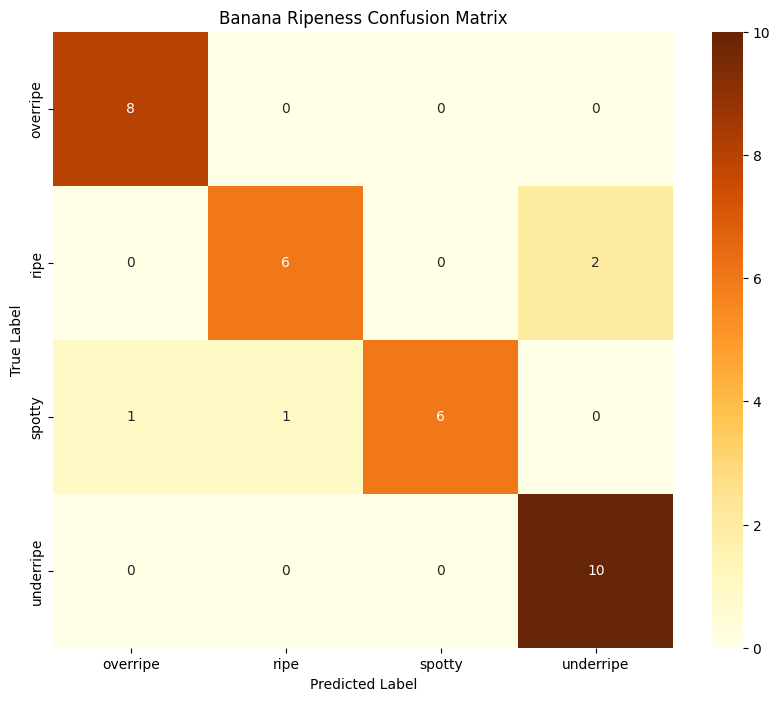


Classification Report:
              precision    recall  f1-score   support

    overripe       0.89      1.00      0.94         8
        ripe       0.86      0.75      0.80         8
      spotty       1.00      0.75      0.86         8
   underripe       0.83      1.00      0.91        10

    accuracy                           0.88        34
   macro avg       0.89      0.88      0.88        34
weighted avg       0.89      0.88      0.88        34



In [ ]:
def plot_confusion_matrix(model, loader, classes):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr', 
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Banana Ripeness Confusion Matrix')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes))

plot_confusion_matrix(model, test_loader, train_data.classes)